First import the functions from the main file, IsingLWE.py

In [14]:
from IsingLWE import *
import time

Call the LWe problem

In [15]:
s = np.load("Instances/s10.npy")
print("s", s)

A = np.load("Instances/A10.npy")
print("A", A)

b = np.load("Instances/b10.npy")
print("b", b)

e = np.load("Instances/e10.npy")
print("e", e)
    # print((s@A+e-b)/3329)

s [-1  2 -2  2 -1 -1  0  1  1 -2]
A [[1234  103  158  839 2714 2971 2304   43   85  269]
 [1481 1413 2031 1305 1996  556 3272  851 3156 3326]
 [1661  102 1384 2592  651  515  255   25 2702 1862]
 [ 374 2010 1400  815 2853  836 1312  800  356 1478]
 [ 421 1624 2923 1590  846  879 1830  769 2488  846]
 [1825 1710 1979 1079   57 2122 1878  420 1916 2200]
 [ 745 1608  645  565 1000   41 2182 3313 1880  609]
 [1127 1992 1098   49 2975 2025 2959 1933  350  571]
 [2165 2770  194 2760 1393  565 2135 2573 3278 1353]
 [1507 1815 2839  134  576 2652  119 1019 2377 1313]]
b [ 516 1006 1305 1416 1336 3055  842 1158 2663 1865]
e [ 1 -2 -1 -2 -1  0 -2 -1  0 -2]


Generate the Ising Ham from the LWE and Bai lattice

In [16]:
NUM_VECTORS = 500


Bai = primal(A, b)

B3 = Bai

bits = 3
n = B3.shape[0]
fixed_idx = n - 1
fixed_val = 1

meta = build_meta_with_fixed3(B3, bits=bits, fixed_idx=fixed_idx, fixed_val=fixed_val, convention="rows")

Q, lin, const = build_qubo_full(meta)



Q_single, c_single = qubo_single_from_full(Q, lin, const)
    # print(Q_single)

Qdict, hdict, Jdict, Q, h, J, ofset = qubo_ising(Q_single)

ofset = ofset + c_single

    # print(ofset)
    # print(h)

where_are_NaNs = np.isnan(J)
J[where_are_NaNs] = 0

where_are_NaNs = np.isnan(h)
h[where_are_NaNs] = 0

J = 2 * J
solver_greedy = SteepestDescentSampler()

implement the algorithm, plotting and the timing and the shortest vector

lowest energies (first 5): [-2.44326889e+09 -2.41716564e+09 -2.38858027e+09 -2.38048684e+09
 -2.36845783e+09]
first state's spins (s1): [-1.  1.  1. -1.  1. -1. -1. -1.  1.  1. -1. -1. -1. -1. -1.  1.  1. -1.
 -1. -1. -1.  1.  1.  1. -1.  1.  1. -1.  1. -1. -1.  1.  1. -1. -1. -1.
  1.  1. -1.  1. -1.  1. -1. -1.  1.  1.  1.  1.  1. -1.  1.  1. -1. -1.
  1.  1.  1. -1. -1. -1.]
check1 5098687.0
<class 'numpy.ndarray'>
v = [1, 3, 1, -1, 2, 2, 2, -3, -3, -2, 460, -54, 188, 441, -1372, -931, 177, -769, 492, -1020, 1]
v = [-2, -2, 1, 0, 2, 2, -3, 2, 0, -3, 966, 224, -578, -227, 419, 963, -1350, -314, -281, -933, 1]
v = [1, 0, 3, -4, -1, 1, 3, 1, 0, -1, -806, 221, 16, 1620, 142, 1144, 245, 394, -487, -517, 1]
v = [-4, 3, 0, -3, -2, -3, -1, 1, 1, 3, 1380, -341, -666, 415, 1543, 82, 216, -275, -223, 435, 1]
v = [1, -1, 3, 2, -4, 2, 0, 2, 0, 1, -708, -1404, -1075, -225, -310, -20, -723, 971, -41, -433, 1]

Initial shortest vector (squared norm): 5098687.00

--- Starting Gauss Sieve ---
Vectors

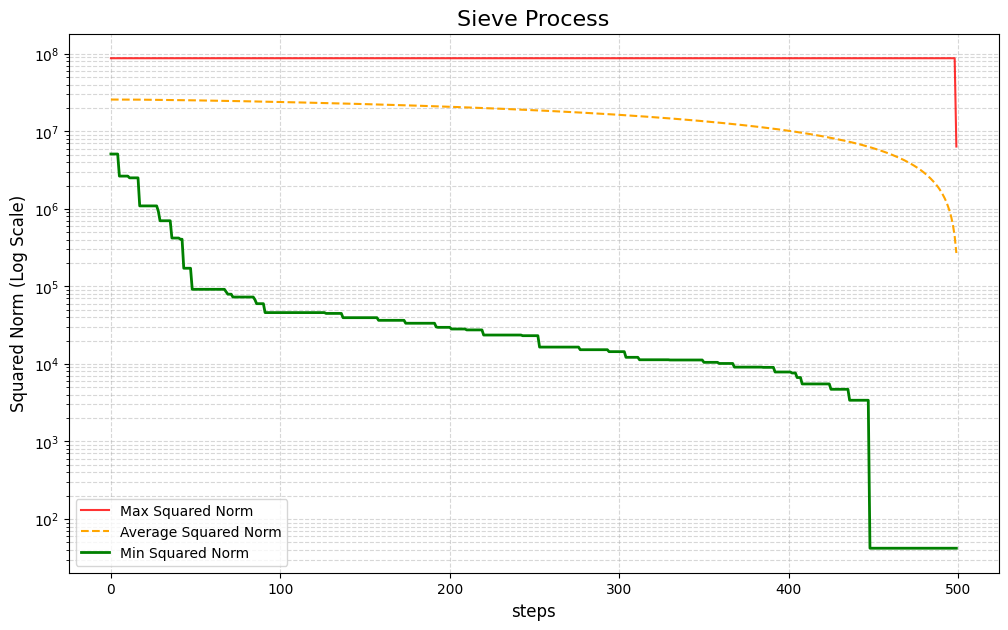

time of the SieveCIM algorithm 5.7777682999148965


In [17]:
for _ in range(1):

        t0 = time.perf_counter()
        solver = CFC(-J, h=-h, batch_size=1000, n_iter=1000, dt=0.4, backend='cpu-float32')
        # print(out['ground_energy']+ofset)
        # print(out['ground_states'])
        # solver.update()

        # # Compute and display results
        energies, spins = solver.calc_energy()
        # sorted_energy, indices = torch.sort(energies)
        # sorted_spins = spins[:, indices]
        # sorted_spins = sorted_spins.T
        # numpy_sorted_spins = sorted_spins.cpu().numpy()

        # s1 = numpy_sorted_spins[:,0]
        # convert to numpy arrays
        energies = to_numpy(energies).ravel()   # ensure 1-D
        spins = to_numpy(spins)

        # make sure spins has shape (n_spins, n_samples)
        if spins.ndim == 1:
            spins = spins.reshape(-1, 1)

        # sort energies and reorder spins accordingly
        indices = np.argsort(energies)          # ascending order
        sorted_energy = energies[indices]
        sorted_spins = spins[:, indices]        # shape (n_spins, n_samples)
        # sorted_spins = sorted_spins.T           # shape (n_samples, n_spins)

        # already numpy, so no .cpu().numpy() needed
        numpy_sorted_spins = sorted_spins.copy()

        # first sample's spin vector
        s1 = numpy_sorted_spins[:, 0]

        # optional: print some results
        print("lowest energies (first 5):", sorted_energy[:5])
        print("first state's spins (s1):", s1)


        # print('Energy values:', sorted_energy[0,0]+ofset)
        # print('Spin configurations (signs):', sorted_spins[0,0])
        sX = sorted_spins.T[0]
        bestS = []
        # print(sX.shape)

        for i in sX:
            bestS.append(int(i))

        bestSnp = np.array(bestS)

        # print(bestSnp)

        s0 = bestSnp
        initial_states = s0_to_initial_states(s0, hdict)
        # print(initial_states)
        sampleset = solver_greedy.sample_ising(hdict, Jdict,
                                               initial_states=initial_states,
                                          num_reads=NUM_VECTORS)
        best_sample = sampleset.first.sample
        best_energy = float(sampleset.first.energy)
        best_samples = sampleset.first.sample
        sumple = []
        print("check1", best_energy+ofset)
        # print("check", best_sample)
        # print(sampleset)
        for i in sampleset.samples():
            sumple.append(i)
            # print(i)
        # print(sumple[0])
        spins_array, labels = dicts_to_spin_list(sumple)
        # print("labels order:", labels)
        # print("spins_array shape:", spins_array.shape)
        # print(spins_array)
        # spins_array shape (num_samples, m) from dicts_to_spin_list(...)
        U, V, norms_sq = spins_array_to_u_v(spins_array, labels, meta, B3)
        print(type(V))
        # Print top few results sorted by norm
        order = np.argsort(norms_sq)
        for idx in order[:5]:
            print(f"v = {V[idx].tolist()}")
        initial_norms = [np.dot(v, v) for v in V]
        print(f"\nInitial shortest vector (squared norm): {min(initial_norms):.2f}")

        final_processed_list, sieve_history = gauss_sieve2(Bai, V)
        t1 = time.perf_counter()
        final_norms = [np.dot(v, v) for v in final_processed_list]
        shortest_vector = final_processed_list[np.argmin(final_norms)]
        print(type(shortest_vector))
        print(f"\nFinal shortest vector (squared norm): {min(final_norms):.2f}")
        print("\nShortest vector found by the sieve:\n", shortest_vector)
        plot_sieving_progress(sieve_history)
        T_total = t1-t0
        minGCIM = sieve_history['min_norm']
        minGCIM = np.array(minGCIM)
        np.save("shorts_of_SieveCIM13",minGCIM)
        print("time of the SieveCIM algorithm", T_total)